<a href="https://colab.research.google.com/github/justwannachill/NM/blob/main/%D0%9B%D0%B0%D0%B16%D0%A8%D0%B8%D0%BB%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder, StandardScaler, LabelEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import os

In [4]:
uploaded = files.upload()


Saving data.csv to data (1).csv


,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang,Cured
0,2.4,18.7,18.4,27.9,7.9,9.6,18.3,13.2,2.5,26.0,10.5,26.2,12.5,0
1,2.1,6.0,15.0,13.3,15.6,13.1,11.0,5.0,7.2,26.0,1.5,13.3,6.2,0
2,17.2,13.9,23.8,6.8,10.7,15.8,19.4,2.7,15.4,21.2,11.1,16.6,11.4,1
3,8.4,9.7,6.8,26.9,4.6,29.1,14.6,19.7,18.0,20.8,13.6,13.9,8.1,1
4,22.1,10.8,16.4,10.5,22.0,23.4,2.6,18.2,23.8,11.3,5.5,16.8,16.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,9.4,2.2,15.8,5.9,29.7,18.7,11.5,13.1,15.3,22.5,10.1,4.7,13.8,0
2334,12.1,7.6,20.6,5.3,18.9,19.1,9.4,11.9,21.8,12.0,26.7,8.4,24.4,1
2335,15.2,33.2,7.2,14.5,16.0,16.7,1.2,32.5,34.5,25.9,3.9,18.0,19.2,1
2336,2.0,17.0,33.2,13.2,29.1,35.5,19.7,30.3,30.7,4.3,15.7,20.5,2.1,1


In [5]:
df = pd.read_csv('data.csv')

df

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang,Cured
0,2.4,18.7,18.4,27.9,7.9,9.6,18.3,13.2,2.5,26.0,10.5,26.2,12.5,0
1,2.1,6.0,15.0,13.3,15.6,13.1,11.0,5.0,7.2,26.0,1.5,13.3,6.2,0
2,17.2,13.9,23.8,6.8,10.7,15.8,19.4,2.7,15.4,21.2,11.1,16.6,11.4,1
3,8.4,9.7,6.8,26.9,4.6,29.1,14.6,19.7,18.0,20.8,13.6,13.9,8.1,1
4,22.1,10.8,16.4,10.5,22.0,23.4,2.6,18.2,23.8,11.3,5.5,16.8,16.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,9.4,2.2,15.8,5.9,29.7,18.7,11.5,13.1,15.3,22.5,10.1,4.7,13.8,0
2334,12.1,7.6,20.6,5.3,18.9,19.1,9.4,11.9,21.8,12.0,26.7,8.4,24.4,1
2335,15.2,33.2,7.2,14.5,16.0,16.7,1.2,32.5,34.5,25.9,3.9,18.0,19.2,1
2336,2.0,17.0,33.2,13.2,29.1,35.5,19.7,30.3,30.7,4.3,15.7,20.5,2.1,1


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2338 entries, 0 to 2337
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Phoenix Feather  2338 non-null   float64
 1   Unicorn Horn     2338 non-null   float64
 2   Dragon's Blood   2338 non-null   float64
 3   Mermaid Tears    2338 non-null   float64
 4   Fairy Dust       2338 non-null   float64
 5   Goblin Toes      2338 non-null   float64
 6   Witch's Brew     2338 non-null   float64
 7   Griffin Claw     2338 non-null   float64
 8   Troll Hair       2338 non-null   float64
 9   Kraken Ink       2338 non-null   float64
 10  Minotaur Horn    2338 non-null   float64
 11  Basilisk Scale   2338 non-null   float64
 12  Chimera Fang     2338 non-null   float64
 13  Cured            2338 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 255.8 KB


In [7]:
df.isnull().sum()

,0
Phoenix Feather,0
Unicorn Horn,0
Dragon's Blood,0
Mermaid Tears,0
Fairy Dust,0
Goblin Toes,0
Witch's Brew,0
Griffin Claw,0
Troll Hair,0
Kraken Ink,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang,Cured
count,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000
mean,15.365697,10.946749,16.115654,13.627973,15.069504,14.157271,12.328914,14.911206,16.871685,14.890590,10.916125,15.371600,12.084003,0.496578
std,8.669969,7.225162,8.372518,7.545244,8.349340,7.831476,7.709753,8.132678,9.579027,8.014197,7.045195,8.559139,8.047540,0.500095
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,8.500000,5.300000,9.600000,7.600000,8.625000,7.900000,6.325000,8.400000,8.900000,8.800000,5.200000,8.800000,5.600000,0.000000
50%,14.700000,9.500000,15.800000,13.100000,14.500000,13.500000,11.200000,14.400000,16.300000,14.400000,9.700000,14.800000,10.500000,0.000000
75%,21.300000,15.575000,22.000000,19.000000,20.700000,19.500000,16.900000,20.500000,24.000000,20.400000,15.375000,21.100000,17.275000,1.000000
max,42.100000,34.100000,40.800000,35.800000,40.400000,37.800000,37.300000,39.400000,44.800000,39.500000,33.700000,42.000000,37.800000,1.000000


In [10]:
df['Cured' ].value_counts ()

,count
Cured,
0,1177
1,1161


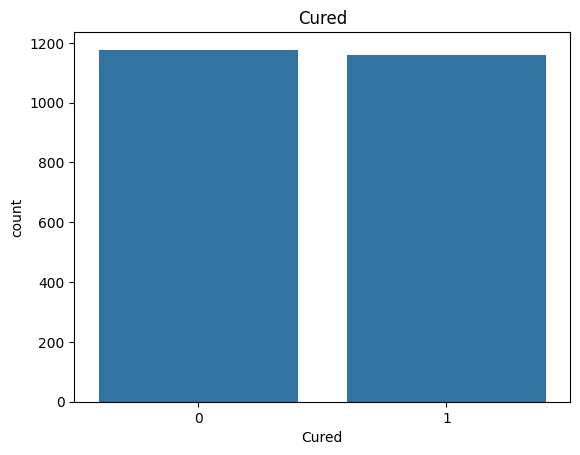

In [11]:
sns.countplot(x='Cured', data=df)
plt.title('Cured')
plt.show()

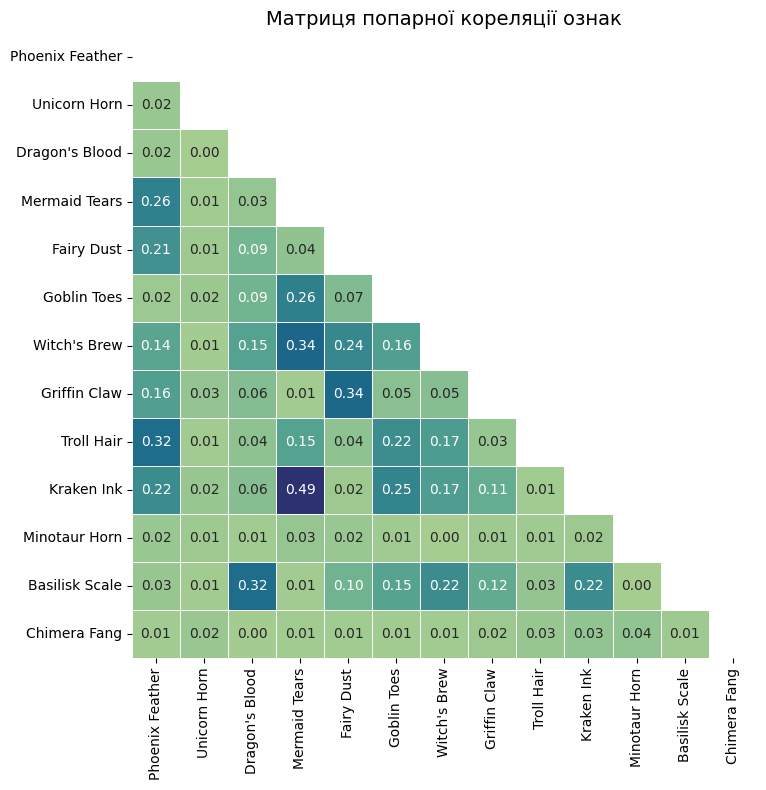

In [12]:
mtx = df.drop('Cured', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    mtx,
    cmap='crest',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
corr_pr = df.corr(numeric_only=True) ['Cured'].abs().sort_values(ascending=False)
corr_pr

,Cured
Cured,1.000000
Troll Hair,0.498165
Witch's Brew,0.245993
Basilisk Scale,0.052436
Goblin Toes,0.046314
Kraken Ink,0.022845
Chimera Fang,0.022144
Phoenix Feather,0.015931
Fairy Dust,0.015004
Minotaur Horn,0.011329


In [18]:
X = df.drop('Cured', axis=1)
y = df ['Cured' ]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nclassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 89.32%

classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       231
           1       0.90      0.89      0.89       237

    accuracy                           0.89       468
   macro avg       0.89      0.89      0.89       468
weighted avg       0.89      0.89      0.89       468



In [25]:
conf = confusion_matrix(y_test, y_pred)
conf

array([[207,  24],
       [ 26, 211]])

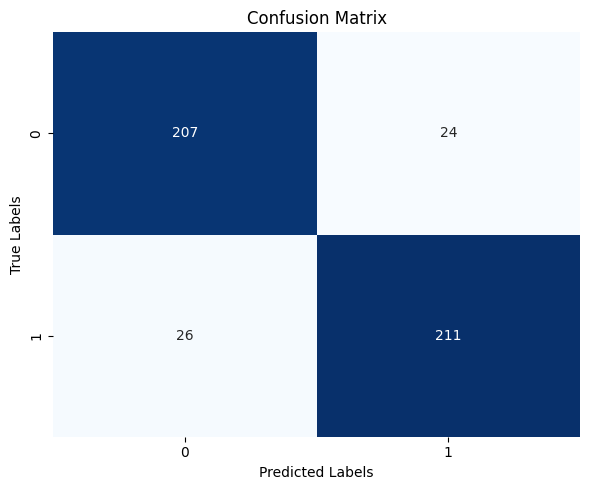

In [27]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=True, yticklabels=True)

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.tight_layout()
plt.show()

In [28]:
# Створюємо датафрейм
comparison_df = pd.DataFrame({
"True Class": y_test.values,
"Predicted Class": y_pred
})

# Вибираємо 10 випадкових зразків
random_samples = comparison_df.sample(10, random_state=42)

print("\n10 випадкових зразків:")
print(random_samples)


10 випадкових зразків:
     True Class  Predicted Class
55            0                1
63            0                0
33            1                0
297           1                1
72            1                1
228           0                0
209           1                1
9             1                1
428           0                0
231           1                1


In [61]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 300]
}

param_dist = {
    'solver': ['liblinear', 'lbfgs'],
    'C': np.logspace(-2, 2, 10),
    'max_iter': [100, 500]
}

In [62]:
grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=3,
    n_jobs=1,
    scoring='accuracy',
    verbose=1
)
grid.fit(X_train_scaled, y_train)
print("GridSearchCV найкращі параметри:")
print(grid.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
GridSearchCV найкращі параметри:
{'C': 10, 'max_iter': 100, 'solver': 'lbfgs'}


In [63]:
random_search = RandomizedSearchCV(
LogisticRegression(),
param_distributions=param_dist,
n_iter=20,
cv=3,
n_jobs =- 1,
scoring='accuracy',
verbose=1,
random_state=42
)
random_search.fit(X_train_scaled, y_train)

print("RandomizedSearchCV найкращі параметри:")
print(random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
RandomizedSearchCV найкращі параметри:
{'solver': 'lbfgs', 'max_iter': 100, 'C': np.float64(100.0)}


In [57]:
best_model = random_search.best_estimator_ # a6o grid.best_estimator_
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nclassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 89.32%

classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       231
           1       0.90      0.89      0.89       237

    accuracy                           0.89       468
   macro avg       0.89      0.89      0.89       468
weighted avg       0.89      0.89      0.89       468



Висновок: Підбір параметрів не впливає на методи моделі

Завдання 2


In [69]:

X = df.iloc[:, :-1]
y = df.iloc[:, -1]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)


tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)


svm_acc = accuracy_score(y_test, y_pred_svm)
tree_acc = accuracy_score(y_test, y_pred_tree)

print("SVM Accuracy:", svm_acc)
print("Decision Tree Accuracy:", tree_acc)

print("\nSVM REPORT:\n", classification_report(y_test, y_pred_svm))
print("\nTREE REPORT:\n", classification_report(y_test, y_pred_tree))




SVM Accuracy: 0.9594017094017094
Decision Tree Accuracy: 0.8354700854700855

SVM REPORT:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       231
           1       0.96      0.96      0.96       237

    accuracy                           0.96       468
   macro avg       0.96      0.96      0.96       468
weighted avg       0.96      0.96      0.96       468


TREE REPORT:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       231
           1       0.86      0.80      0.83       237

    accuracy                           0.84       468
   macro avg       0.84      0.84      0.84       468
weighted avg       0.84      0.84      0.84       468



Висновок: У ході роботи було побудовано дві моделі: метод опорних векторів (SVM) та дерево рішень.
За результатами оцінювання точності встановлено, що модель SVM показала значно кращий результат (0.96) у порівнянні з деревом рішень (0.84).

Це пояснюється тим, що SVM ефективніше знаходить оптимальну межу між класами та краще узагальнює дані, тоді як дерево рішень схильне до переобучення.

Отже, для даного набору даних доцільно обрати модель SVM.